# Synapse parameterization of a circuit

Assign physiological synapse parameters &mdash; drawn from statistical model distributions &mdash;
to the synapses of a **circuit** using the `SynapseParameterization` task.

A parameterization is composed of four kinds of building block, wired together by reference:

- **Distributions** &mdash; the statistical distributions individual parameters are drawn from.
- **Synaptic models** &mdash; a `ExcitatoryTsodyksMarkramSynapticModel` groups one distribution per synapse
  parameter (conductance, decay time, number of vesicles, ...).
- **Neuron sets** &mdash; source / target populations used to select *which* synapses to parameterize.
- **Synapse model assigners** &mdash; map a synaptic model onto a subset of an edge population.

This notebook demonstrates **all three** assigner types:

| Assigner | Synapses it parameterizes |
| --- | --- |
| `AllPairsSynapticModelAssigner` | every synapse in an edge population |
| `InterNeuronSetSynapticModelAssigner` | synapses between a source and a target neuron set |
| `PresynapticNeuronSetSynapticModelAssigner` | synapses *from* a source neuron set |

Assigners that share an edge population are applied in insertion order on top of a default
parameterization, so later (more specific) assigners refine earlier (broader) ones.

In [1]:
import shutil
from pathlib import Path

import numpy as np
import obi_one as obi
from entitysdk import Client
from obi_auth import get_token
from obi_notebook import get_projects

## Connect to the platform

The circuit used below lives in the **staging** environment.

In [2]:
environment = "staging"
token = get_token(environment=environment)
project_context = get_projects.get_projects(token=token, env=environment)

client = Client(project_context=project_context, token_manager=token, environment=environment)

Dropdown(description='Select:', options=(('Proximal vs. distal inhibition', {'id': '32008ab5-76cf-47cd-b98b-a5…

## Select the circuit

We use a public circuit in staging. `CircuitFromID` works with any circuit (it does not require
the "single" scale that the `MEModelWithSynapsesCircuitFromID` wrapper does).

In [3]:
# Public circuit in staging
circuit_id = "53d2432c-3951-4930-876f-ced17305c163"
circuit_from_id = obi.CircuitFromID(id_str=circuit_id)

# Staged circuits and the parameterized output are written here (outside the repo)
output_root = Path("../../../../obi-output/synapse_parameterization")
coordinate_output_root = output_root / "parameterized_circuit"

## Inspect the circuit

Stage the circuit once (into the entity cache the task will reuse) and look at its edge
populations and node sets to decide what to parameterize.

In [4]:
circuit_entity = circuit_from_id.entity(db_client=client)
print(f"Circuit: {circuit_entity.name}  (id {circuit_entity.id}, scale {circuit_entity.scale})")

# Stage into the same entity cache the task reuses, so the circuit is only downloaded once
cache_dir = output_root.resolve() / "entity_cache" / "sonata_circuit" / str(circuit_entity.id)
circuit = circuit_from_id.stage_circuit(db_client=client, dest_dir=cache_dir, entity_cache=True)
sonata = circuit.sonata_circuit

print("\nEdge populations:")
for ep_name in sonata.edges.population_names:
    ep = sonata.edges[ep_name]
    print(f"  {ep_name}: {ep.source.name} -> {ep.target.name}  ({ep.size} synapses)")

# Parameterize the default intrinsic edge population (biophysical -> biophysical).
# Fall back gracefully if the default is ambiguous; you can also set this manually.
try:
    edge_population_name = circuit.default_edge_population_name
except ValueError:
    edge_population_name = None
if edge_population_name is None:
    intrinsic = [
        name
        for name in sonata.edges.population_names
        if sonata.edges[name].source.name == sonata.edges[name].target.name
    ]
    edge_population_name = (intrinsic or list(sonata.edges.population_names))[0]
ep = sonata.edges[edge_population_name]
print(
    f"\nParameterizing edge population '{edge_population_name}' "
    f"({ep.source.name} -> {ep.target.name}, {ep.size} synapses)"
)

available_node_sets = set(circuit.node_sets)
print(
    "Excitatory / Inhibitory node sets available:",
    "Excitatory" in available_node_sets,
    "/",
    "Inhibitory" in available_node_sets,
)

Circuit: nbS1-O1-sSub-pre-dim5-nCN-HEX0-L1-01  (id 53d2432c-3951-4930-876f-ced17305c163, scale small)

Edge populations:
  POm__S1nonbarrel_neurons__chemical: POm -> S1nonbarrel_neurons  (857 synapses)
  S1nonbarrel_neurons__S1nonbarrel_neurons__chemical: S1nonbarrel_neurons -> S1nonbarrel_neurons  (87 synapses)
  VPM__S1nonbarrel_neurons__chemical: VPM -> S1nonbarrel_neurons  (14 synapses)
  external_S1nonbarrel_neurons__S1nonbarrel_neurons__chemical: external_S1nonbarrel_neurons -> S1nonbarrel_neurons  (7442 synapses)

Parameterizing edge population 'S1nonbarrel_neurons__S1nonbarrel_neurons__chemical' (S1nonbarrel_neurons -> S1nonbarrel_neurons, 87 synapses)
Excitatory / Inhibitory node sets available: True / True


## Build the configuration

Start from an empty config and add blocks to it. `config.add(block, name=...)` stores the block in
the appropriate dictionary and creates a reference (`block.ref`) that other blocks can point to.

In [5]:
config = obi.SynapseParameterizationSingleConfig.empty_config()

config.set(
    obi.Info(
        campaign_name="Synapse parameterization",
        campaign_description=f"Physiological parameterization of circuit {circuit_entity.name}",
    ),
    name="info",
)
config.set(config.Initialize(circuit=circuit_from_id), name="initialize")

### Synaptic models and their distributions

Each `ExcitatoryTsodyksMarkramSynapticModel` needs one distribution per synapse parameter. The helper below
adds the distributions to the config and wires the model to reference them. The default values
follow the platform's standard Tsodyks-Markram model; here the excitatory and inhibitory models
differ only in their conductance distribution (illustrative values).

In [6]:
exc_gamma_dist = obi.GammaDistribution(shape=4.0, scale=0.25)
config.add(exc_gamma_dist, "Excitatory conductance distribution")

inh_gamma_dist = obi.GammaDistribution(shape=8.0, scale=0.25)
config.add(inh_gamma_dist, "Inhibitory conductance distribution")


# Excitatory model
excitatory_model = obi.ExcitatoryTsodyksMarkramSynapticModel(
    conductance_distribution=exc_gamma_dist.ref
)

# Inhibitory model (larger conductance, inhibitory synapse type id)
inhibitory_model = obi.InhibitoryTsodyksMarkramSynapticModel(
    conductance_distribution=inh_gamma_dist.ref
)
config.add(excitatory_model, "Excitatory synaptic model")
config.add(inhibitory_model, "Inhibitory synaptic model")

print("Synaptic models:", list(config.synaptic_models.keys()))
print("Distributions:", len(config.distributions))

Synaptic models: ['Excitatory synaptic model', 'Inhibitory synaptic model']
Distributions: 2


### Neuron sets

The inter- and presynaptic assigners select synapses by the neuron set of the pre/post-synaptic
neurons. We fall back to "all neurons" if the circuit does not define `Excitatory` / `Inhibitory`
node sets.

In [7]:
all_neurons = obi.AllNeurons()
config.add(all_neurons, name="AllNeurons")

if "Excitatory" in available_node_sets:
    excitatory_neurons = obi.ExcitatoryNeurons()
    config.add(excitatory_neurons, name="ExcitatoryNeurons")
else:
    excitatory_neurons = all_neurons
    print("No 'Excitatory' node set - using all neurons as the excitatory source set.")

if "Inhibitory" in available_node_sets:
    inhibitory_neurons = obi.InhibitoryNeurons()
    config.add(inhibitory_neurons, name="InhibitoryNeurons")
else:
    inhibitory_neurons = all_neurons
    print("No 'Inhibitory' node set - using all neurons as the inhibitory source set.")

### Synapse model assigners

All three assigner types target the same edge population, so they are layered in the order they are
added: a broad baseline first, then progressively more specific refinements.

1. **`AllPairsSynapticModelAssigner`** &mdash; baseline: every synapse gets the excitatory model.
2. **`InterNeuronSetSynapticModelAssigner`** &mdash; synapses from *inhibitory* to *all* neurons get
   the inhibitory model.
3. **`PresynapticNeuronSetSynapticModelAssigner`** &mdash; synapses *from excitatory* neurons get the
   excitatory model.

In [8]:
# 1. Baseline: assign the excitatory model to EVERY synapse in the edge population
all_pairs_assigner = obi.AllPairsSynapticModelAssigner(
    edge_population_name=edge_population_name,
    synaptic_model=excitatory_model.ref,
)
config.add(all_pairs_assigner, name="all_pairs")

# 2. Refine: inhibitory -> all synapses get the inhibitory model
inter_assigner = obi.InterNeuronSetSynapticModelAssigner(
    edge_population_name=edge_population_name,
    synaptic_model=inhibitory_model.ref,
    source_neuron_set=inhibitory_neurons.ref,
    targeted_neuron_set=all_neurons.ref,
)
config.add(inter_assigner, name="inhibitory_pathways")

# 3. Refine: synapses FROM excitatory neurons get the excitatory model
presyn_assigner = obi.PresynapticNeuronSetSynapticModelAssigner(
    edge_population_name=edge_population_name,
    synaptic_model=excitatory_model.ref,
    source_neuron_set=excitatory_neurons.ref,
)
config.add(presyn_assigner, name="excitatory_pathways")

print("Assigners:", list(config.synapse_model_assigners.keys()))

Assigners: ['all_pairs', 'inhibitory_pathways', 'excitatory_pathways']


## Finalize and run the task

Resolving the block references links every assigner to its synaptic model and neuron sets, and
every synaptic model to its distributions.

Running the task stages the circuit, writes the drawn parameters into the SONATA edge files, and
finally performs a **dry-run registration** of the parameterized circuit as a derivation of the
original (validating the metadata against the platform without persisting anything).

In [9]:
# Resolve references: assigner -> model / neuron sets, and model -> distributions
config.fill_block_references_and_names()

# Output locations for the staged + parameterized circuit
config.scan_output_root = output_root
config.coordinate_output_root = coordinate_output_root

task = obi.SynapseParameterizationTask(config=config)

In [10]:
# The task copies the staged circuit into a fresh output directory; clear a previous run's output
if coordinate_output_root.exists():
    shutil.rmtree(coordinate_output_root)

task.execute(db_client=client, entity_cache=True)
print("Done. Parameterized circuit written to:", coordinate_output_root.resolve())

/Users/james/Documents/obi/code/obi-main/temp/obi-one/obi_one/scientific/blocks/synaptic_model_assigners/base.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94
 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94
 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94
 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94
 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94
 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94 1.94
 1.94 1.94 1.94]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  params.update(new_params)
/Users/james/Documents/obi/code/obi-main/temp/obi-one/obi_one/scientific/blocks/synaptic_model_assigners/base.py:80: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a 

Done. Parameterized circuit written to: /Users/james/Documents/obi/code/obi-main/temp/obi-output/synapse_parameterization/parameterized_circuit


## Inspect the parameterized synapses

Open the parameterized circuit and check that the physiological properties were written. The
`synapse_type_id` counts reveal the layering: synapses keep the excitatory or inhibitory model id
depending on which assigner last touched them.

In [11]:
parameterized = obi.Circuit(
    name="parameterized_circuit",
    path=str(coordinate_output_root / "circuit_config.json"),
).sonata_circuit
edges = parameterized.edges[edge_population_name]

physiology_props = [
    p for p in obi.ExcitatoryTsodyksMarkramSynapticModel.parameter_names() if p in edges.property_names
]
print(f"{edge_population_name}: {edges.size} synapses")
print("Parameterized properties:", physiology_props)

# Sample synapses for a quick look at the assigned distributions
ids = edges.ids()
if len(ids) > 50_000:
    ids = np.sort(np.random.default_rng(0).choice(ids, 50_000, replace=False))
syn_table = edges.get(ids, properties=physiology_props)

print("\nsynapse_type_id counts (excitatory vs inhibitory model layering):")
print(syn_table["synapse_type_id"].value_counts())

syn_table.head()

S1nonbarrel_neurons__S1nonbarrel_neurons__chemical: 87 synapses
Parameterized properties: ['u_hill_coefficient', 'conductance', 'conductance_scale_factor', 'facilitation_time', 'depression_time', 'n_rrp_vesicles', 'decay_time', 'usyn', 'delay', 'synapse_type_id']

synapse_type_id counts (excitatory vs inhibitory model layering):
synapse_type_id
113    51
7      36
Name: count, dtype: int64


,u_hill_coefficient,conductance,conductance_scale_factor,facilitation_time,depression_time,n_rrp_vesicles,decay_time,usyn,delay,synapse_type_id
0,1.94,1.092254,0.7,18.271990,675.042419,1,1.734558,0.586396,2.345584,113
1,1.94,1.084125,0.7,18.192251,674.814087,3,1.782162,0.700000,2.821618,113
2,1.94,1.421967,0.7,21.384874,683.516296,1,1.733044,0.582609,2.330437,113
3,1.94,0.682898,0.7,14.002956,661.825134,2,1.700000,0.200000,0.696843,113
4,1.94,1.102503,0.7,18.372280,675.328674,2,1.790536,0.700000,2.905356,113


array([[<Axes: title={'center': 'u_hill_coefficient'}>,
        <Axes: title={'center': 'conductance'}>,
        <Axes: title={'center': 'conductance_scale_factor'}>],
       [<Axes: title={'center': 'facilitation_time'}>,
        <Axes: title={'center': 'depression_time'}>,
        <Axes: title={'center': 'n_rrp_vesicles'}>],
       [<Axes: title={'center': 'decay_time'}>,
        <Axes: title={'center': 'usyn'}>,
        <Axes: title={'center': 'delay'}>]], dtype=object)

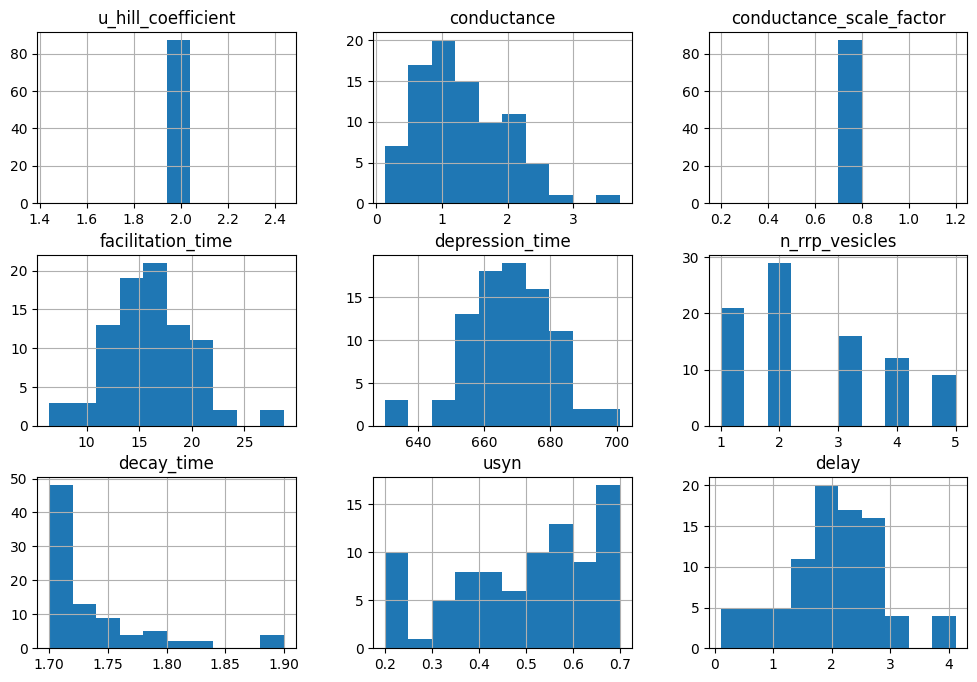

In [12]:
syn_table.drop(columns=["synapse_type_id"]).hist(figsize=(12, 8))